## 문제: Forward Euler 방법으로 1차 상미분 방정식 풀기

다음과 같은 1차 상미분 방정식(Ordinary Differential Equation, ODE)이 주어졌을 때,

$$\frac{dy}{dt} = -0.5y$$

초기 조건 $y(0) = 1$ 에서 Forward Euler 방법을 사용하여 $t=0$ 부터 $t=10$ 까지의 시간 범위에서 $y(t)$ 값을 예측하는 코드를 PyTorch로 작성하세요.

**해석적 해:**
이 ODE의 해석적 해는 $y(t) = e^{-0.5t}$ 입니다. 코드에서 Forward Euler 방법으로 얻은 결과와 비교해보세요.

**파라미터:**
*   초기 시간 $t_0 = 0$
*   최종 시간 $t_{end} = 10$
*   시간 간격 $\Delta t = 0.1$
*   초기 조건 $y(0) = 1$
*   상수 $k = 0.5$

tensor y0: 1.0, size_y0 : torch.Size([])
t_values:  [0.0]
y_euler:  [1.0]
======step 1=======
dydt:  tensor(-0.5000)
y_next:  tensor(0.5000)
t_next:  1.0
t_values:  [0.0, 1.0]
y_euler:  [1.0, 0.5]
======step 2=======
dydt:  tensor(-0.2500)
y_next:  tensor(0.2500)
t_next:  2.0
t_values:  [0.0, 1.0, 2.0]
y_euler:  [1.0, 0.5, 0.25]
======step 3=======
dydt:  tensor(-0.1250)
y_next:  tensor(0.1250)
t_next:  3.0
t_values:  [0.0, 1.0, 2.0, 3.0]
y_euler:  [1.0, 0.5, 0.25, 0.125]
======step 4=======
dydt:  tensor(-0.0625)
y_next:  tensor(0.0625)
t_next:  4.0
t_values:  [0.0, 1.0, 2.0, 3.0, 4.0]
y_euler:  [1.0, 0.5, 0.25, 0.125, 0.0625]
======step 5=======
dydt:  tensor(-0.0312)
y_next:  tensor(0.0312)
t_next:  5.0
t_values:  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
y_euler:  [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]
======step 6=======
dydt:  tensor(-0.0156)
y_next:  tensor(0.0156)
t_next:  6.0
t_values:  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
y_euler:  [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]
===

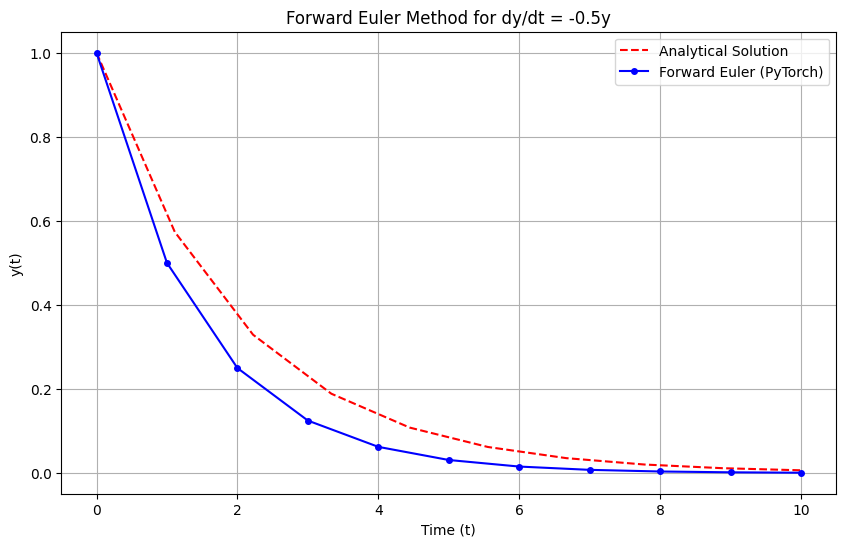

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. ODE 함수 정의: dy/dt = -k * y
def ode_function(y, t, k):
    return -k * y

# 2. 파라미터 설정
k = 0.5
y0 = torch.tensor(1.0)  # 초기 조건
print(f"tensor y0: {y0}, size_y0 : {y0.size()}")
t0 = 0.0
t_end = 10.0
dt = 1.0  # 시간 간격
# 시간 스텝 수 계산
num_steps = int((t_end - t0) / dt)

# 결과를 저장할 리스트 초기화
t_values = [t0]
y_euler = [y0.item()] # .item()으로 Python float으로 변환하여 저장
print("t_values: ", t_values)
print("y_euler: ", y_euler)

# Forward Euler 방법 구현
y_current = y0
t_current = t0

for i in range(num_steps):
  print(f"======step {i+1}=======")
  #dy/dt 계산
  dydt = ode_function(y_current, t_current, k)
  print("dydt: ", dydt)
  # Forward Euler 업데이트 규칙
  y_next = y_current + dydt * dt
  print("y_next: ", y_next)

  # 시간 업데이트
  t_next = t_current + dt
  print("t_next: ", t_next)
  # 결과 저장
  t_values.append(t_next)
  print("t_values: ", t_values)
  y_euler.append(y_next.item())
  print("y_euler: ", y_euler)

  # 다음 스텝을 위해 값 업데이트
  y_current = y_next
  t_current = t_next

# 3. 결과 시각화

# # 해석적 해 계산
t_analytical = np.linspace(t0, t_end, 10)
y_analytical = np.exp(-k * t_analytical)

plt.figure(figsize=(10, 6))
plt.plot(t_analytical, y_analytical, label='Analytical Solution', color='red', linestyle='--')
plt.plot(t_values, y_euler, label='Forward Euler (PyTorch)', color='blue', marker='o', markersize=4)
plt.title('Forward Euler Method for dy/dt = -0.5y')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()


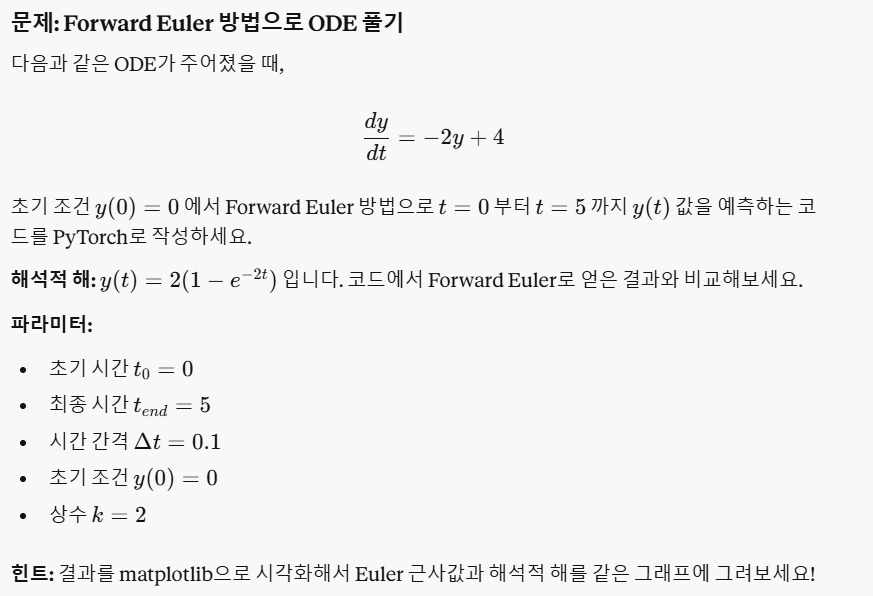


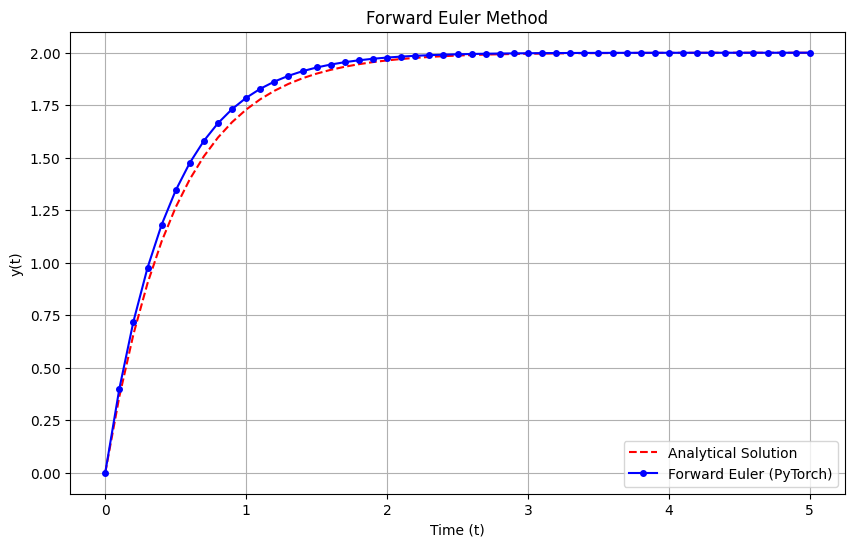

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 초기값 설정 및 ode함수 생성
def ode_function(t, y, k):
  return -k*y + 4.0

k=2.0
y0 = torch.tensor(0.0)
t0 = 0.0
t_end = 5.0
step = 0.1
total_step = int((t_end - t0)/ step)

#forward 오일러 적용 : y_(i+1) = y_i + dy/dt * step
t_values = [t0]
y_values = [y0.item()]

t_current = t0
y_current = y0
for i in range(1,total_step+1):
  #print(f"====step{i}=====")

  y_next = y_current + ode_function(t_current, y_current, k) * step
  #print("y_next: ",y_next)
  t_next = t_current + step
  #print("t_next: ",t_next)

  t_values.append(t_next)
  #print("t_values: ",t_values)
  y_values.append(y_next.item())
  #print("y_values: ",y_values)

  t_current = t_next
  y_current = y_next

#print(len(y_values))

# 해석적 해 계산
t_analytical = np.linspace(t0, t_end, total_step+1)
#print(t_analytical.size)
y_analytical = 2*(1 - np.exp(-k * t_analytical))

plt.figure(figsize=(10, 6))
plt.plot(t_analytical, y_analytical, label='Analytical Solution', color='red', linestyle='--')
plt.plot(t_values, y_values, label='Forward Euler (PyTorch)', color='blue', marker='o', markersize=4)
plt.title('Forward Euler Method')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()








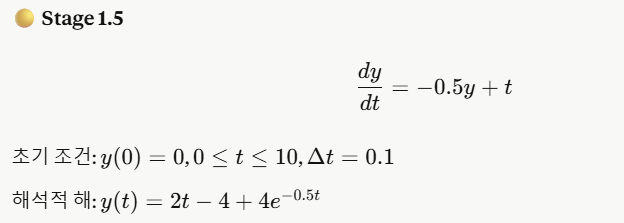

100


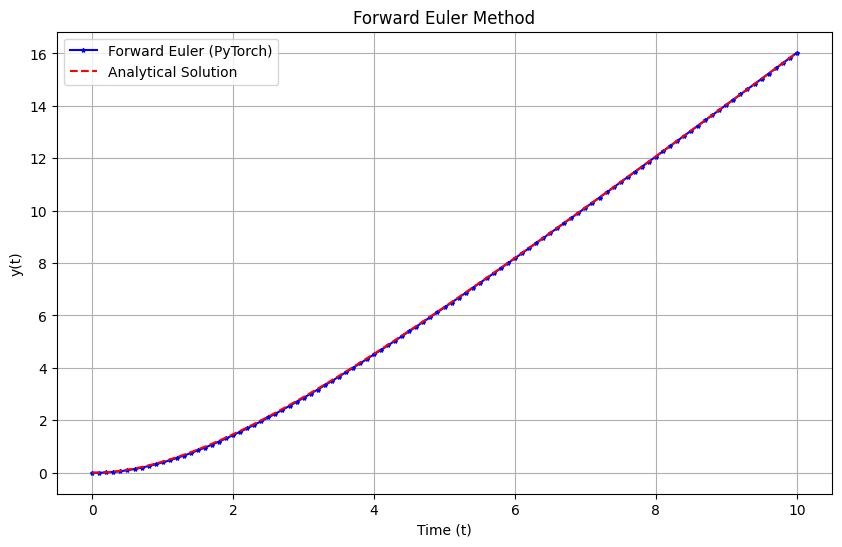

In [36]:
# t 일반버전, t tensor 버전
import torch
import numpy as np
import matplotlib.pyplot as plt

def ode_function(t,y,k):
  return -k*y + t

k = 0.5
y0 = torch.tensor(0.0)
#t0 = 0.0; t_end = 10.0; step = 0.1
t0 = torch.tensor(0.0)
t_end = torch.tensor(10.0)
total_step = int((t_end.item() - t0.item())/ step)
print(total_step)

# t_values = [t0]
t_values = [t0.item()]
y_values = [y0.item()]

t_current = t0
y_current = y0

for i in range(1, total_step + 1):
  y_next = y_current + ode_function(t_current, y_current, k) * step

  t_next = t_current + step

  t_values.append(t_next)
  y_values.append(y_next.item())

  t_current = t_next
  y_current = y_next


# t_analytical = np.linspace(t0, t_end, total_step+1)
t_analytical = np.linspace(t0.item(), t_end.item(), total_step+1)
y_analytical = 2*t_analytical - 4.0 + 4*np.exp(-k * t_analytical)

plt.figure(figsize=(10, 6))
plt.plot(t_values, y_values, label='Forward Euler (PyTorch)', color='blue', marker='*', markersize=3.0)
plt.plot(t_analytical, y_analytical, label='Analytical Solution', color='red', linestyle='--')

plt.title('Forward Euler Method')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()
